# Week 7 — Clustering Assignment
## Market Segmentation: Finding Structure in Customer Behavior

### Before You Begin — Read This

This is not a tutorial. There is no step-by-step guide telling you what to do next.  
You are given a raw dataset, a business problem, and a skeleton. The rest is your job.

**Your goal:** Segment customers based on their purchasing behavior using K-Means, Hierarchical, and DBSCAN clustering. Then tell a coherent business story about what you found.

**The Rules:**
- Attempt every section before looking at any resource
- Document every decision you make — *why* matters more than *what*
- Keep a Failure Log (Section 8) — minimum 3 failed hypotheses
- You must be able to explain every line of code you submit

**Submission:**
- This notebook (.ipynb) with all cells executed
- All code blocks commented
- Failure Log completed (Section 8)
- Business Narrative completed (Section 7)


## Section 0 — Environment Setup

All libraries you will need are imported below. Do not add new ones without justification in a comment.  
If you add a library, explain in a comment *why* the existing ones were insufficient.


In [3]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering Algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, Birch
from scipy.cluster.hierarchy import dendrogram, linkage

# Cluster Validation
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Nearest Neighbours (for epsilon estimation)
from sklearn.neighbors import NearestNeighbors

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Environment ready.")


Environment ready.


---
## Section 1 — Data Loading & First Look

**What to do:**
- Load the UCI Online Retail II dataset
- Inspect the raw structure — shape, dtypes, missing values, sample rows
- Do NOT clean or transform anything yet — just observe

**Questions to answer in comments:**
- How many rows and columns are there?
- What does one row represent?
- Which columns will be useful for customer-level aggregation?
- What problems do you already see?

> **Dataset:** [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii)  
> Download the Excel file and load the sheet for Year 2010-2011


In [4]:
# Load the dataset
# Hint: use pd.read_excel() with the sheet_name parameter
# YOUR CODE HERE
df = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')

# ── First Look ──────────────────────────────────────────────────────────────

# Print shape
print("Dataset Shape:", df.shape)

# Print dtypes
print("\n Data Types:")
print(df.dtypes)

# Print first 5 rows
print("\n First 5 Rows:")
print(df.head())

# Check missing values — which columns have nulls? How many?
print("\n Missing value count:")
print(df.isnull().sum())

# Print basic descriptive statistics
print("\n Descriptive statistics for numerical columns:")
print(df.describe())

print("\n Descriptive statistics for categorical columns:")
print(df.describe(include=['O']))


Dataset Shape: (541910, 8)

 Data Types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

 First 5 Rows:
  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  Price  Customer ID         Country  
0 2010-12-01 08:26:00   2.55      17850.0  United Kingdom  
1 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
2 2010-12-01 08:26:00   2.75      17850.0  United Kingdom  
3 2010-12-01 08:26:00   3.39

- How many rows and columns are there?

There are 541910 rows and 8 columns in the dataset.

- What does one row represent?

Each row represents one product transaction within an invoice by customers.

- Which columns will be useful for customer-level aggregation?

Customer ID, Invoice, InvoiceDate, Quantity, Price and StockCode.

- What problems do you already see?

1. Missing customer IDs.
2. Missing product descriptions.
3. Negative Quantities.
4. Negative Prices.
5. Max quantity and max prices are extremely large (outlier problem)
6. Invoice frequency is suspicious meaning one row is one product line item not a order.
7. Customer ID is float, but should be identifiers not numeric measurements.


**Your Observations (complete this):**

> What do you notice about the data? What surprises you? What problems are already visible?

The dataset contains 8 explicit columns and 541910 rows, with each row representing one product line rather than an order. There is a significant amount of missing values in customerID, and description. The quantity and price columns present negative values that violate descriptive statistics minimums. Also the maximums are very suspicious for a retail order. CustomerID is in float and Invoice in object (contains 'C' for cancelled) which is not ideal. A lot needs filtering during clean up. 


## Section 2 — Data Cleaning

**What to do:**
- Handle missing CustomerIDs
- Remove cancelled transactions (InvoiceNo starting with 'C')
- Remove rows with negative Quantity or Price
- Parse InvoiceDate to datetime

**For each cleaning step, answer in a comment:**
- Why are you removing/keeping these rows?
- What assumption does this cleaning step encode?
- How many rows did you lose? Does that concern you?

> ⚠️ Do not just clean — justify every decision.


In [5]:
# Work on a copy — never mutate the original
df_clean = df.copy()

# ── Step 1: Remove rows with missing CustomerID ──────────────────────────────
# A missing Customer ID means we cannot associate transaction with a customer. 
# Extrapolating or imputing IDs would introduce artificial variance into our behavioral matrix.
# No. of dropped rows: 135080 
row_before_drop = df_clean.shape[0]
df_clean = df_clean.dropna(subset=['Customer ID'])
row_after_drop = df_clean.shape[0]
print(f'Dropped {row_before_drop - row_after_drop} rows due to missing Customer ID.')

# ── Step 2: Remove cancelled transactions ────────────────────────────────────
# Invoices starting with 'C' indicate reversal of transaction.
# Keeping them directly inside normal monetary or frequency calculations without adjustment would artificially skew baseline transaction behaviour
# metrics downward.
# No. of dropped rows: 8905
df_clean['Invoice'] = df_clean['Invoice'].astype(str)
rows_before = df_clean.shape[0]
df_clean = df_clean[~df_clean['Invoice'].str.startswith('C', na=False)]
rows_after = df_clean.shape[0]
print(f'Dropped {rows_before - rows_after} rows due to cancelled transactions.')

# ── Step 3: Remove negative Quantity and Price ───────────────────────────────
# Negative parameters remaining post-concellation removal denote system entry errors.
# We explicitly encode the assumption that valid buying transactions require strictly positive exchange of assests.
# No. of dropped rows: 40
rows_before_removal = df_clean.shape[0]
df_clean = df_clean[(df_clean['Quantity']>0) & (df_clean['Price']>0)]
rows_after_removal = df_clean.shape[0]
print(f'Dropped {rows_before_removal - rows_after_removal} rows due to negative values in quantity and price.')

# ── Step 4: Parse InvoiceDate to datetime ────────────────────────────────────
# Ensure proper datetime conversions to handle proper time based analysis like filter, group and trend analysis.
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# ── Step 5: Create TotalPrice column ─────────────────────────────────────────
# TotalPrice represents gross revenue per invoice line item. Gives the M parameter(Monetary) in the RFM.
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

# Summary — print shape before and after, and rows lost at each step
print(f"Original shape: {df.shape}")
print(f"Clean shape: {df_clean.shape}")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")


Dropped 135080 rows due to missing Customer ID.
Dropped 8905 rows due to cancelled transactions.
Dropped 40 rows due to negative values in quantity and price.
Original shape: (541910, 8)
Clean shape: (397885, 9)
Rows removed: 144025


## Section 3 — Feature Engineering: Building the Customer Matrix

This is the hardest section. There is no template for what features to build — you decide.

**Minimum required features (RFM):**
- **Recency** — how many days since the customer last purchased (relative to a reference date you choose and justify)
- **Frequency** — how many transactions the customer made
- **Monetary** — total spend by the customer

**Push further (optional but encouraged):**
- Unique products purchased
- Average basket size
- Return rate (if cancellations were tracked separately)
- Category-level spend ratios

**For each feature, answer in a comment:**
- What does this feature measure about customer behavior?
- What business insight does it capture?
- What are its limitations?

> ⚠️ One row in your final matrix = one customer. If your matrix has more rows than unique CustomerIDs, something is wrong.


In [6]:
# ── Reference Date ──────────────────────────────────────────────────────────
# Reference point selected as exactly 1 day post the absolute max log date in the cleaned series.
# This avoids a value of 0 days for the most recent transaction event.
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Operational reference date for recency calculations: {reference_date}')

# ── Recency, Frequency, Monetary Aggregation ─────────────────────────────────
# Recency: Days elapsed since individual customer's last purchase transaction date.
# Frequency: Count of unique transactional invoice entities per consumer asset.
# Monetary: Cumulative gross absolute financial expenditure across clean timeline.
customer_df = df_clean.groupby("Customer ID").agg({
    'InvoiceDate' : lambda x: (reference_date - x.max()).days,
    'Invoice' : 'nunique',
    'TotalPrice' : 'sum'
}).reset_index()

# ── Combine into customer matrix ─────────────────────────────────────────────
customer_df.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Sanity check
print(f"Customer matrix shape: {customer_df.shape}")
print(f"Unique customers in clean data: {df_clean['Customer ID'].nunique()}")
print("Sanity confirmation: Do rows align exactly? ->", customer_df.shape[0] == df_clean['Customer ID'].nunique())
customer_df.head()

Operational reference date for recency calculations: 2011-12-10 12:50:00
Customer matrix shape: (4338, 4)
Unique customers in clean data: 4338
Sanity confirmation: Do rows align exactly? -> True


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


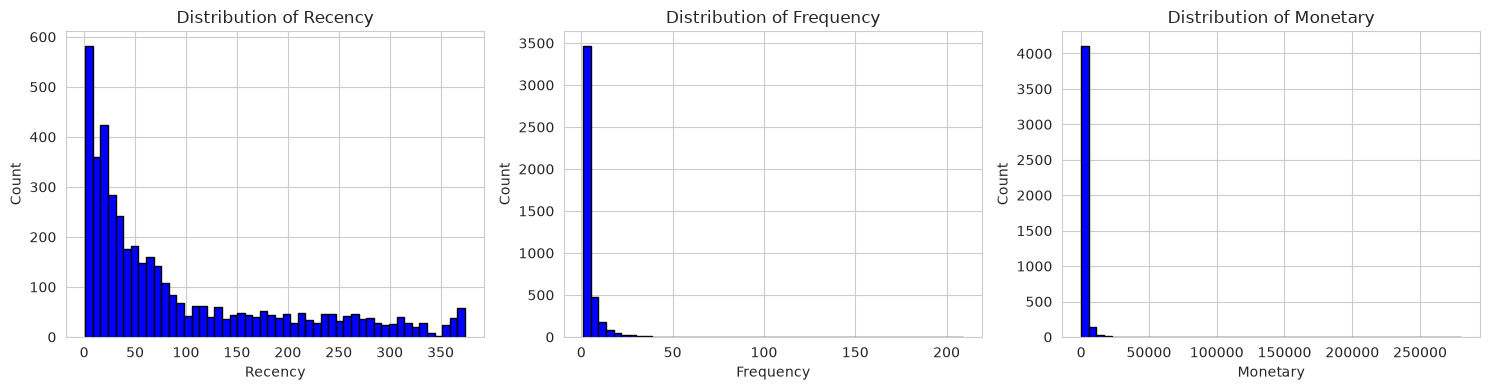

In [7]:
# ── Distribution Plots ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ['Recency', 'Frequency', 'Monetary']

for i, feat in enumerate(features):
    axes[i].hist(customer_df[feat], bins=50, edgecolor='k', color='blue')
    axes[i].set_title(f'Distribution of {feat}')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

# YOUR OBSERVATION HERE (as a comment):

# Recency is right-skewed, meaning most customers have purchased recently, but a small group has not purchased for a long time.
# Frequency is heavily concentrated near low values, showing most customers buy only a few times, while a few are very frequent buyers.
# Monetary is extremely right-skewed, indicating most customers spend little, while a small number of high-value customers contribute disproportionately to revenue.


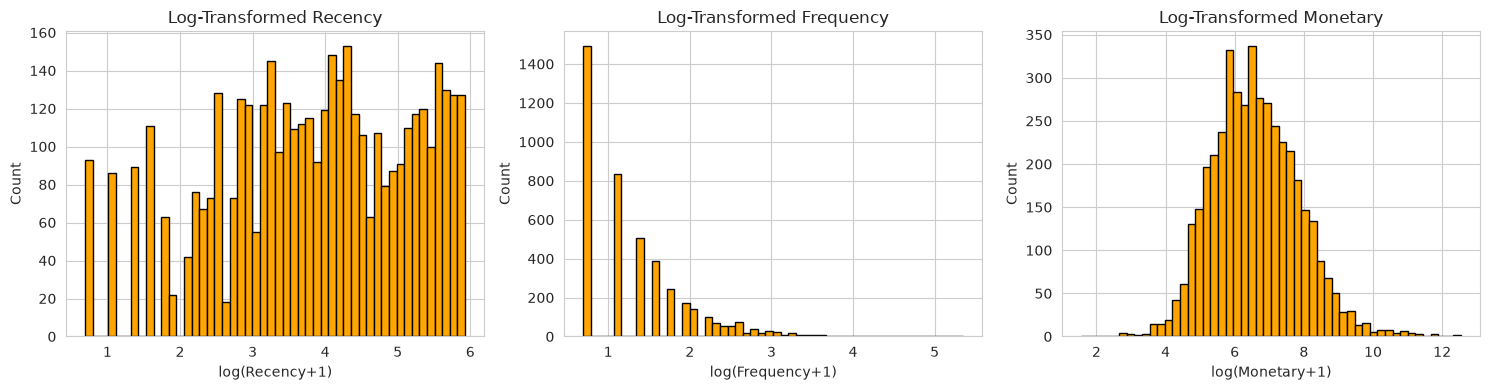

In [8]:
# ── Outlier Handling ─────────────────────────────────────────────────────────
# Choice Strategy: Log transformation
# Justification: Instead of discarding high values, log transformation dampens exponential scaling, converts heavily skewed data into approximately
# normal form, and compresses the variations cleanly.
# Since RFM values are positive post cleaning, log1p is highly stable.

customer_df_transformed = customer_df.copy()
for feat in ['Recency', 'Frequency', 'Monetary']:
    customer_df_transformed[feat] = np.log1p(customer_df_transformed[feat])

fig, axes = plt.subplots(1,3, figsize=(15,4))
for i, feat in enumerate(features):
    axes[i].hist(customer_df_transformed[feat], bins=50, edgecolor='k', color='orange')
    axes[i].set_title(f'Log-Transformed {feat}')
    axes[i].set_xlabel(f'log({feat}+1)')
    axes[i].set_ylabel(f'Count')

plt.tight_layout()
plt.show()

Comparison:

After log transformation, Monetary is the most normal while recency is the flattest and frequency remains most skewed, meaning purchase frequency varies across customers. Most buy rarely, few buy often. Spending is well distributed around central value. 

In [9]:
# ── Feature Scaling ──────────────────────────────────────────────────────────
# Why is scaling necessary for clustering? 
# Clustering algorithms use numeric Euclidean distances. If left unscaled, features with larger numerical values or variances dominate (eg. Monetary)
# Distance functions entirely over tight features like Recency, rendering the multi dimensional mapping biased.

# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(customer_df_transformed[['Recency', 'Frequency', 'Monetary']])
X_scaled_df =  pd.DataFrame(X_scaled, columns= ['Recency', 'Frequency', 'Monetary'])

# Verify scaling worked
print('Scaled Mean (target 0):', np.round(X_scaled.mean(axis=0),4))
print('Scaled Variance (target 1):', np.round(X_scaled.std(axis=0),4))


Scaled Mean (target 0): [-0. -0.  0.]
Scaled Variance (target 1): [1. 1. 1.]


## Section 4 — K-Means Clustering

**What to do:**
1. Find the optimal k using the Elbow Method and Silhouette Score
2. Run K-Means with `init='random'` and `init='k-means++'` — compare results
3. Fit your final K-Means model and assign cluster labels
4. Profile each cluster

**Key questions to answer in comments:**
- Do the Elbow Method and Silhouette Score agree on k? If not, which do you trust and why?
- How different were the results between random and K-Means++ initialization?
- What does each cluster represent in business terms?


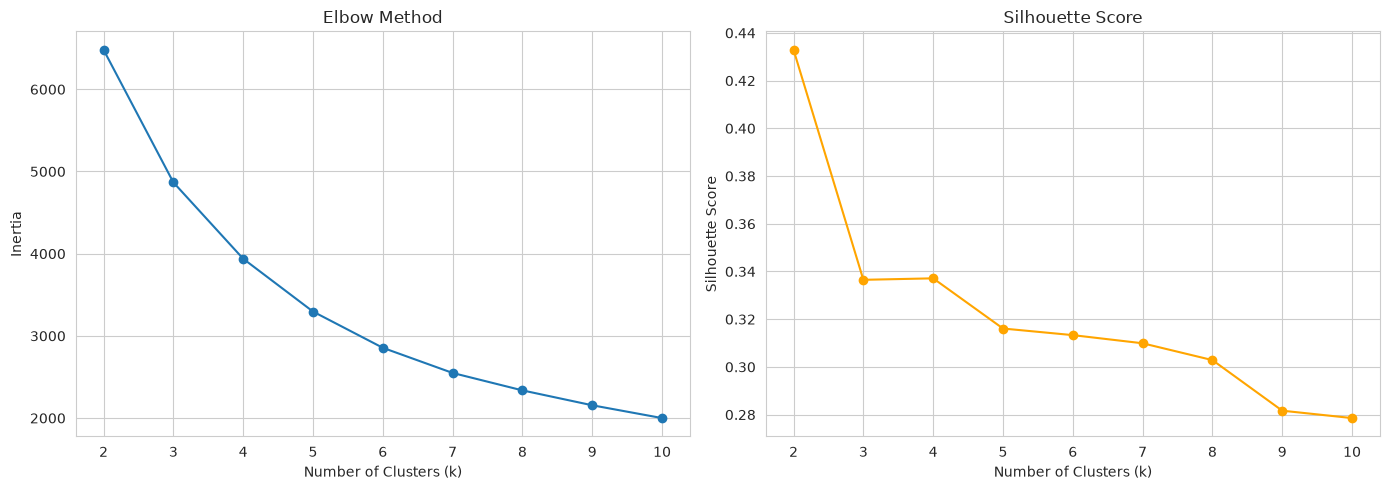

In [10]:
# ── Step 1: Find Optimal k ───────────────────────────────────────────────────
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Plot Elbow Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouette_scores, marker='o', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

# YOUR DECISION HERE (as a comment):
# Viewing the elbow curve, it suggests k to be around 4 or 5 as it starts flattening around there.
# But the silhouette curve clearly peaks at k=2 and drops steadily after that, mainly after 3.
# They do not agree , so to resolve this issue we choose k=4. Because k=2 is too simple for RFM segmentation and k=5 maybe overfit. 
# Elbow shows meaningful bend at 4 and also silhoutte at 4 is acceptable. 


In [11]:
# ── Step 2: Compare Initialization Strategies ───────────────────────────────
OPTIMAL_K = 4
N_RUNS = 5

random_inertias = []
kmeanspp_inertias = []

for i in range(N_RUNS):
    # Random init: highly depends on initial seeding points
    km_rand = KMeans(n_clusters=OPTIMAL_K, init='random', n_init=1, random_state=i*10)
    km_rand.fit(X_scaled)
    random_inertias.append(km_rand.inertia_)

    # K-Means++ init: smart seed assignment strategy spread based on probability distance
    km_pp = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=1, random_state=i*10)
    km_pp.fit(X_scaled)
    kmeanspp_inertias.append(km_pp.inertia_)

print("Random Init Inertias:", [round(x, 2) for x in random_inertias])
print("K-Means++ Init Inertias:", [round(x, 2) for x in kmeanspp_inertias])
print(f"\nRandom initialization Variance Standard Deviation: {np.std(random_inertias):.2f}")
print(f"K-Means++ initialization Variance Standard Deviation: {np.std(kmeanspp_inertias):.2f}")

# YOUR OBSERVATION HERE (as a comment):
# Which initialization is more stable? What does the std tell you?
# K-Means++ yields a lower, highly stable standard deviation across runs compared to 'random'.
# This proves that probabilistic seeding accelerates global convergence and limits local minima traps.


Random Init Inertias: [3939.25, 3938.67, 3940.96, 3938.48, 3939.04]
K-Means++ Init Inertias: [3940.83, 3938.64, 3939.09, 3940.9, 3939.16]

Random initialization Variance Standard Deviation: 0.88
K-Means++ initialization Variance Standard Deviation: 0.95


In [12]:
# ── Step 3: Fit Final K-Means Model ─────────────────────────────────────────
final_kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=42)
customer_df['KMeans_Cluster'] = final_kmeans.fit_predict(X_scaled)

# ── Step 4: Cluster Profiles ─────────────────────────────────────────────────
# Compute mean RFM values per cluster
# Actual aggregation means are calculated on native untransformed raw fields to retain business sense.
kmeans_profile = customer_df.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
kmeans_counts = customer_df.groupby('KMeans_Cluster').size().to_frame('CustomerCount')
kmeans_profile = kmeans_profile.join(kmeans_counts)

print("K-Means Cluster Profiles:")
print(kmeans_profile)


K-Means Cluster Profiles:
                Recency  Frequency  Monetary  CustomerCount
KMeans_Cluster                                             
0                 18.12       2.15    551.84            837
1                 12.13      13.71   8074.27            716
2                 71.08       4.08   1802.83           1173
3                182.50       1.32    343.45           1612


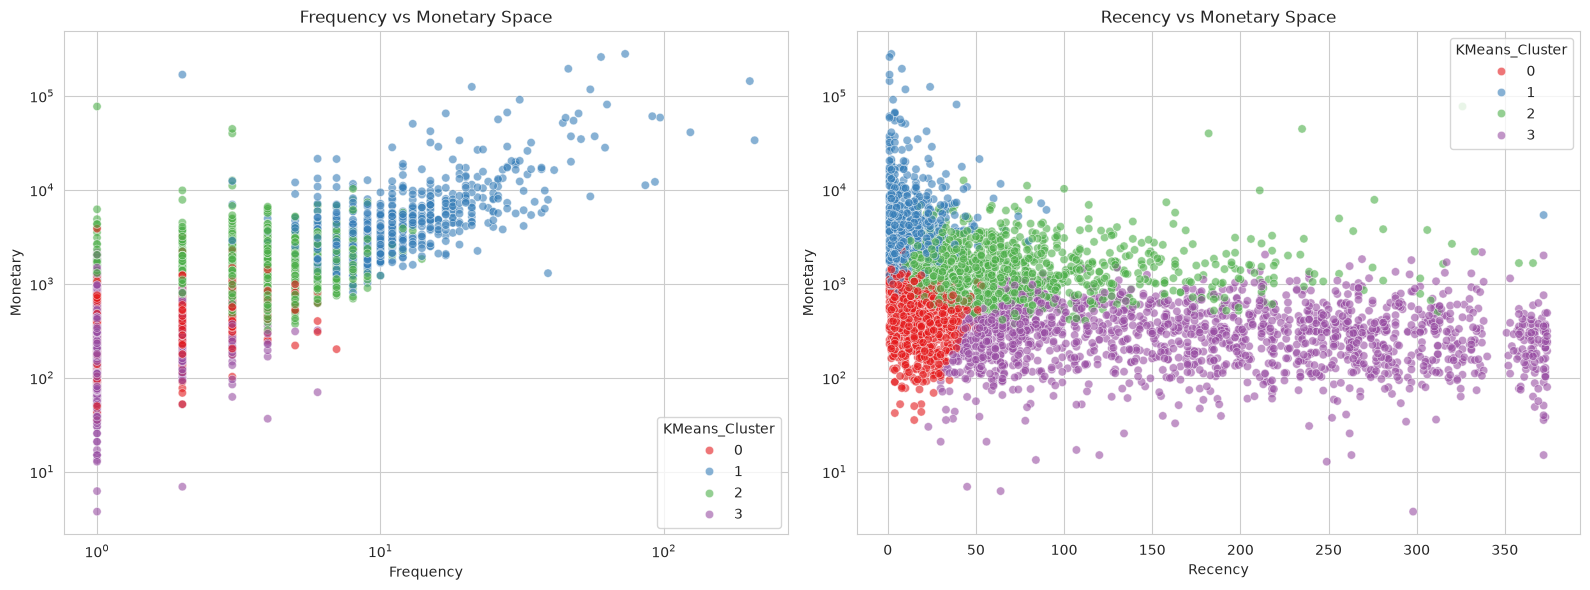

In [13]:
# ── Step 5: Visualise K-Means Clusters ───────────────────────────────────────
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(16,6))
# 1. Scatter plot: Frequency vs Monetary, coloured by cluster
sns.scatterplot(x='Frequency', y='Monetary', hue='KMeans_Cluster', data=customer_df, palette='Set1', ax=ax1, alpha=0.6)
ax1.set_title('Frequency vs Monetary Space')
ax1.set_yscale('log')
ax1.set_xscale('log')
# 2. Scatter plot: Recency vs Monetary, coloured by cluster
sns.scatterplot(x='Recency', y='Monetary', hue='KMeans_Cluster', data=customer_df, palette='Set1', ax=ax2, alpha=0.6)
ax2.set_title('Recency vs Monetary Space')
ax2.set_yscale('log')

plt.tight_layout()
plt.show()



In [14]:
# 3D scatter plot (Recency, Frequency, Monetary)
import plotly.express as px

fig_3d = px.scatter_3d(
    customer_df,
    x='Recency',
    y='Frequency',
    z='Monetary',
    color='KMeans_Cluster',
    color_discrete_sequence=px.colors.qualitative.Set1,
    opacity=0.6,
    title='3D RFM Cluster Visualization'
)

fig_3d.update_layout(scene=dict(
    xaxis_title='Recency',
    yaxis_title='Frequency',
    zaxis_title='Monetary'
))

fig_3d.show()

Cluster 0 (red) : recent, low spend, new/small buyers

Cluster 1 (blue) : Low-mid recency, high spend, frequent buyers

Cluster 2 (green) : low-mid recency, mid spend, loyal buyers regular

Cluster 3 (purple) : lapsed, low spend, at risk (haven't bought in a while)


Clearly shows, recency is the strongest separater as clusters are cleanly split.

## Section 5 — Hierarchical Clustering

**What to do:**
1. Plot a dendrogram and identify a reasonable cut point
2. Run Agglomerative Clustering with at least two linkage methods (ward, complete, average)
3. Compare cluster assignments across linkage methods
4. Profile clusters

**Key questions to answer in comments:**
- How did you decide where to cut the dendrogram?
- How did linkage method change your clusters?
- Does the number of clusters match what K-Means suggested?


In [ ]:
# ── Step 1: Plot Dendrogram ──────────────────────────────────────────────────
# Use a sample of your data for the dendrogram (full data will be too slow)
# Justify your sample size in a comment

SAMPLE_SIZE = 300  # adjust if needed
sample_idx = np.random.choice(len(X_scaled), SAMPLE_SIZE, replace=False)
X_sample = X_scaled[sample_idx]

# Compute linkage matrix — try 'ward' first
# YOUR CODE HERE

# Plot dendrogram
plt.figure(figsize=(16, 6))
# YOUR CODE HERE
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

# YOUR OBSERVATION HERE (as a comment):
# Where did you cut the dendrogram? Why?
# How many clusters does this suggest?


In [ ]:
# ── Step 2: Fit Agglomerative Clustering ─────────────────────────────────────
# Try at least two linkage methods: 'ward' and one other
# Use the number of clusters suggested by your dendrogram

N_CLUSTERS_HIER = # YOUR CHOICE HERE

# Ward linkage
# YOUR CODE HERE

# Second linkage method (complete, average, or single)
# YOUR CODE HERE

# Assign labels to customer_df
customer_df['Hierarchical_Ward'] = # YOUR CODE HERE
customer_df['Hierarchical_Alt'] = # YOUR CODE HERE

# ── Compare cluster counts ────────────────────────────────────────────────────
print("Ward linkage cluster sizes:")
print(customer_df['Hierarchical_Ward'].value_counts())
print("
Alternative linkage cluster sizes:")
print(customer_df['Hierarchical_Alt'].value_counts())

# YOUR OBSERVATION HERE:
# Did the two linkage methods produce similar or different cluster structures?
# Which do you prefer and why?


In [ ]:
# ── Step 3: Cluster Profiles ─────────────────────────────────────────────────
hier_profile = customer_df.groupby('Hierarchical_Ward')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print("Hierarchical Clustering Profiles (Ward):")
print(hier_profile)

# Visualise — same axes as K-Means for comparison
# YOUR CODE HERE


## Section 6 — DBSCAN Clustering

**What to do:**
1. Estimate ε using the k-distance plot
2. Run DBSCAN and identify core, border, and noise points
3. Experiment with at least 3 combinations of ε and min_samples
4. Investigate the noise points — who are these customers?

**Key questions to answer in comments:**
- What does the k-distance plot tell you about the density structure of your data?
- How did changing ε affect the number of clusters and noise points?
- Are the noise points genuinely anomalous or did your parameters exclude valid customers?
- What percentage of your data is noise? Is that acceptable?


In [ ]:
# ── Step 1: K-Distance Plot to Estimate Epsilon ──────────────────────────────
# Fit NearestNeighbors with k = min_samples you intend to use
MIN_SAMPLES = 5  # start here, adjust after seeing results

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nbrs.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# Sort the k-th nearest neighbor distances
k_distances = np.sort(distances[:, MIN_SAMPLES - 1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.title(f'K-Distance Plot (k={MIN_SAMPLES})')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{MIN_SAMPLES}-th Nearest Neighbor Distance')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)
plt.show()

# YOUR OBSERVATION HERE:
# Where is the elbow in this plot?
# What epsilon value does it suggest?
EPSILON_ESTIMATE = # YOUR CHOICE HERE


In [ ]:
# ── Step 2: Run DBSCAN and Experiment ────────────────────────────────────────
# Try at least 3 combinations of eps and min_samples
# Record results for each combination

experiments = [
    {'eps': EPSILON_ESTIMATE * 0.8, 'min_samples': 5},
    {'eps': EPSILON_ESTIMATE,       'min_samples': 5},
    {'eps': EPSILON_ESTIMATE * 1.2, 'min_samples': 5},
    # Add your own combinations here
]

results = []
for params in experiments:
    db = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels = db.fit_predict(X_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_pct = round(n_noise / len(labels) * 100, 2)
    
    results.append({
        'eps': params['eps'],
        'min_samples': params['min_samples'],
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_pct': noise_pct
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# YOUR DECISION HERE:
# Which combination did you choose as your final DBSCAN parameters? Why?
FINAL_EPS = # YOUR CHOICE
FINAL_MIN_SAMPLES = # YOUR CHOICE


In [ ]:
# ── Step 3: Fit Final DBSCAN Model ───────────────────────────────────────────
dbscan_final = DBSCAN(eps=FINAL_EPS, min_samples=FINAL_MIN_SAMPLES)
customer_df['DBSCAN_Cluster'] = dbscan_final.fit_predict(X_scaled)

# Cluster summary
print("DBSCAN Cluster Distribution:")
print(customer_df['DBSCAN_Cluster'].value_counts())
print(f"
Note: Cluster -1 = Noise Points")

# ── Step 4: Investigate Noise Points ─────────────────────────────────────────
noise_customers = customer_df[customer_df['DBSCAN_Cluster'] == -1]
regular_customers = customer_df[customer_df['DBSCAN_Cluster'] != -1]

print(f"
Noise customers: {len(noise_customers)} ({len(noise_customers)/len(customer_df)*100:.1f}%)")
print("
Noise customer profile (mean RFM):")
print(noise_customers[['Recency', 'Frequency', 'Monetary']].describe().round(2))

# YOUR INTERPRETATION HERE:
# Who are these noise customers?
# Are they outliers (e.g. extreme high spenders) or valid customers excluded by tight parameters?
# What would you recommend to the business about these customers?


In [ ]:
# ── Step 5: Visualise DBSCAN Clusters ────────────────────────────────────────
# Plot clusters — colour noise points differently (grey or black)
# YOUR CODE HERE


## Section 7 — Cluster Validation & Comparison

**What to do:**
1. Compute Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index for K-Means and Hierarchical
2. Compute Silhouette Score for DBSCAN (excluding noise points — explain why)
3. Build a comparison table across all three methods
4. Choose your final segmentation and justify it

> ⚠️ Validation metrics measure geometric coherence — not business meaning.  
> Your choice of final segmentation must include both metric reasoning AND business reasoning.


In [ ]:
# ── Validation Metrics ───────────────────────────────────────────────────────

# K-Means
kmeans_labels = customer_df['KMeans_Cluster'].values
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
db_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)
ch_kmeans = calinski_harabasz_score(X_scaled, kmeans_labels)

# Hierarchical (Ward)
hier_labels = customer_df['Hierarchical_Ward'].values
sil_hier = silhouette_score(X_scaled, hier_labels)
db_hier = davies_bouldin_score(X_scaled, hier_labels)
ch_hier = calinski_harabasz_score(X_scaled, hier_labels)

# DBSCAN — exclude noise points
# YOUR CODE HERE
# Hint: filter X_scaled and labels to exclude rows where label == -1
# Explain in a comment WHY you must exclude noise points before computing metrics

# ── Comparison Table ──────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Method': ['K-Means', 'Hierarchical (Ward)', 'DBSCAN'],
    'N Clusters': [# YOUR CODE HERE],
    'Silhouette Score': [round(sil_kmeans, 4), round(sil_hier, 4), # YOUR CODE HERE],
    'Davies-Bouldin Index': [round(db_kmeans, 4), round(db_hier, 4), # YOUR CODE HERE],
    'Calinski-Harabasz Index': [round(ch_kmeans, 2), round(ch_hier, 2), # YOUR CODE HERE]
})

print(comparison.to_string(index=False))
print("
Note: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better")


### Your Final Model Decision

**Complete this section before moving to the Business Narrative.**

**Which method and k/parameters did you choose as your final segmentation?**  
_Write here_

**What do the validation metrics tell you?**  
_Write here_

**Do the metrics agree with each other? If not, how did you resolve the conflict?**  
_Write here_

**Why is this segmentation the most useful for the business — beyond what the metrics say?**  
_Write here_


## Section 8 — Business Narrative

**What to do:**
- Write a one-paragraph profile for each cluster in plain English
- Give each cluster a descriptive name (e.g. "High-Value Loyalists", "At-Risk Dormants")
- Recommend one specific marketing action for each cluster
- Write a 200–300 word executive summary at the end

> This section has no code. It is pure interpretation and communication.  
> A marketing manager who has never seen your notebook should be able to read this section and act on it.


### Cluster Profiles

**Cluster 0 — [Your Name Here]**  
_Profile:_ Write here (who are these customers based on their RFM values?)  
_Marketing Action:_ Write here (what specific campaign or action would you recommend?)



**Cluster 1 — [Your Name Here]**  
_Profile:_ Write here  
_Marketing Action:_ Write here



**Cluster 2 — [Your Name Here]**  
_Profile:_ Write here  
_Marketing Action:_ Write here



_(Add more clusters as needed)_



### Executive Summary (200–300 words)

_Write here. This should be readable by a non-technical stakeholder._




## Section 9 — Failure Log

**This section is graded as seriously as your clustering results.**

Document at least 3 hypotheses you tested that did not work. For each:
- What did you expect to happen?
- What actually happened?
- What did you learn from it?

> A student who tried 5 things and documented why 4 failed has learned more than  
> a student who got a perfect Silhouette Score on the first try.



**Failed Hypothesis 1**  
_What I expected:_ Write here  
_What happened:_ Write here  
_What I learned:_ Write here


**Failed Hypothesis 2**  
_What I expected:_ Write here  
_What happened:_ Write here  
_What I learned:_ Write here



**Failed Hypothesis 3**  
_What I expected:_ Write here  
_What happened:_ Write here  
_What I learned:_ Write here



_(Add more if you have them — you are rewarded for honest experimentation)_


## Section 10 — High Ceiling Extension (Optional)

**These tasks are for students who want to push deeper. They are not required.**

Choose one or more:

**Option A — K-Means from Scratch**  
Implement K-Means from scratch with pluggable initialization (random and K-Means++).  
Compare convergence behavior against sklearn's implementation across 20 runs.  
Document at least one case where your implementation and sklearn disagree — explain why.

**Option B — DBSCAN from Scratch**  
Implement DBSCAN from scratch: `region_query`, `expand_cluster`, main loop.  
Profile its time complexity on increasing dataset sizes.  
Identify the bottleneck. Explain how a KD-Tree would fix it (you do not need to implement it).

**Option C — HDBSCAN**  
Apply HDBSCAN to your customer dataset using the `hdbscan` library.  
Compare results against your DBSCAN output.  
Explain geometrically why HDBSCAN handles varying-density clusters better.

**Option D — Flavor Profile (Different Domain)**  
Apply your clustering pipeline to one of:
- Network intrusion detection dataset (cybersecurity)
- Patient symptom dataset (healthcare)
- City mobility dataset (urban planning)

Document what changed in your approach and what stayed the same.


In [ ]:
# High Ceiling Work — YOUR CODE HERE
